[2026-07-31 13:57:15] [info     ] 计算因子，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-31 13:57:24] [info     ] 读取因子库，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-31 13:57:24] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-31 13:57:26] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-31 13:57:26] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-31 13:57:27] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-31 13:57:27] [info     ] ========== 数据检查 ==========
[2026-07-31 13:57:27] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg

时段,IC
2024-01-15~2024-02-08,0.0200
2024-09-24~2024-10-08,-0.0520

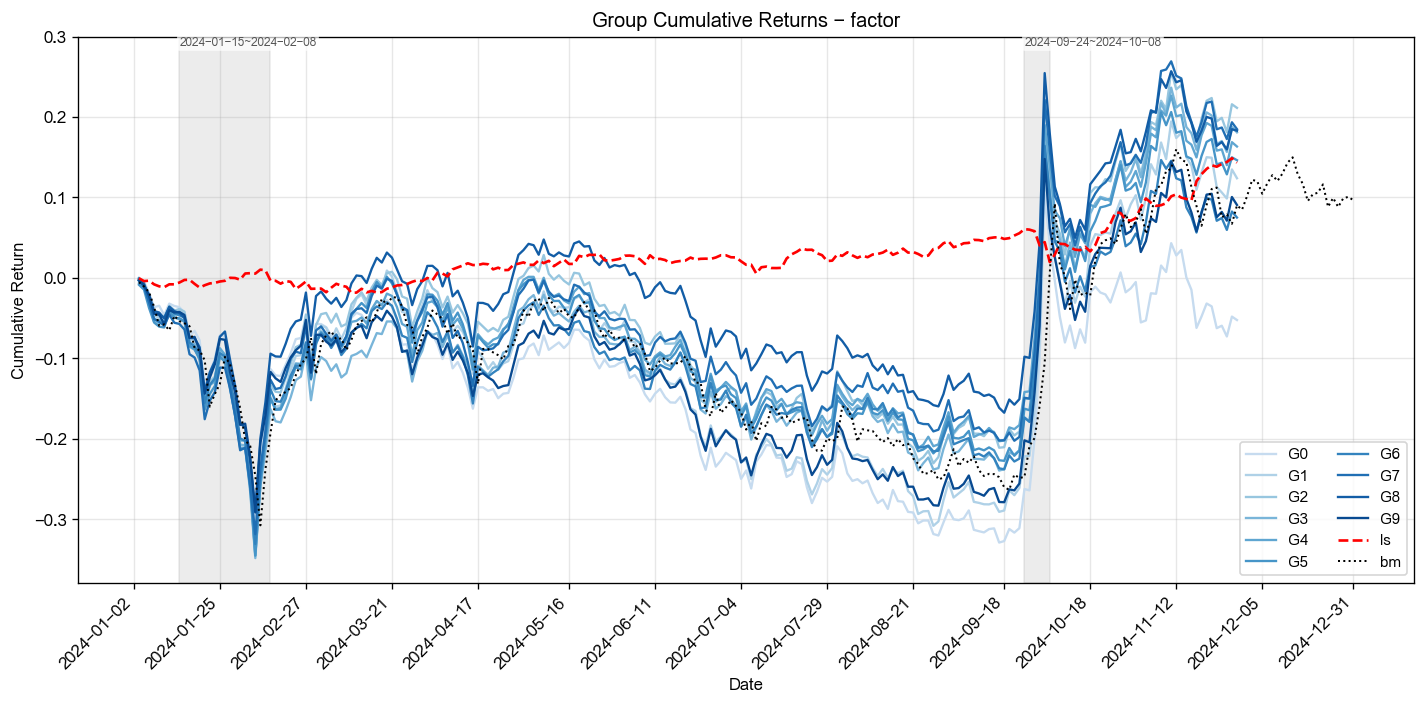
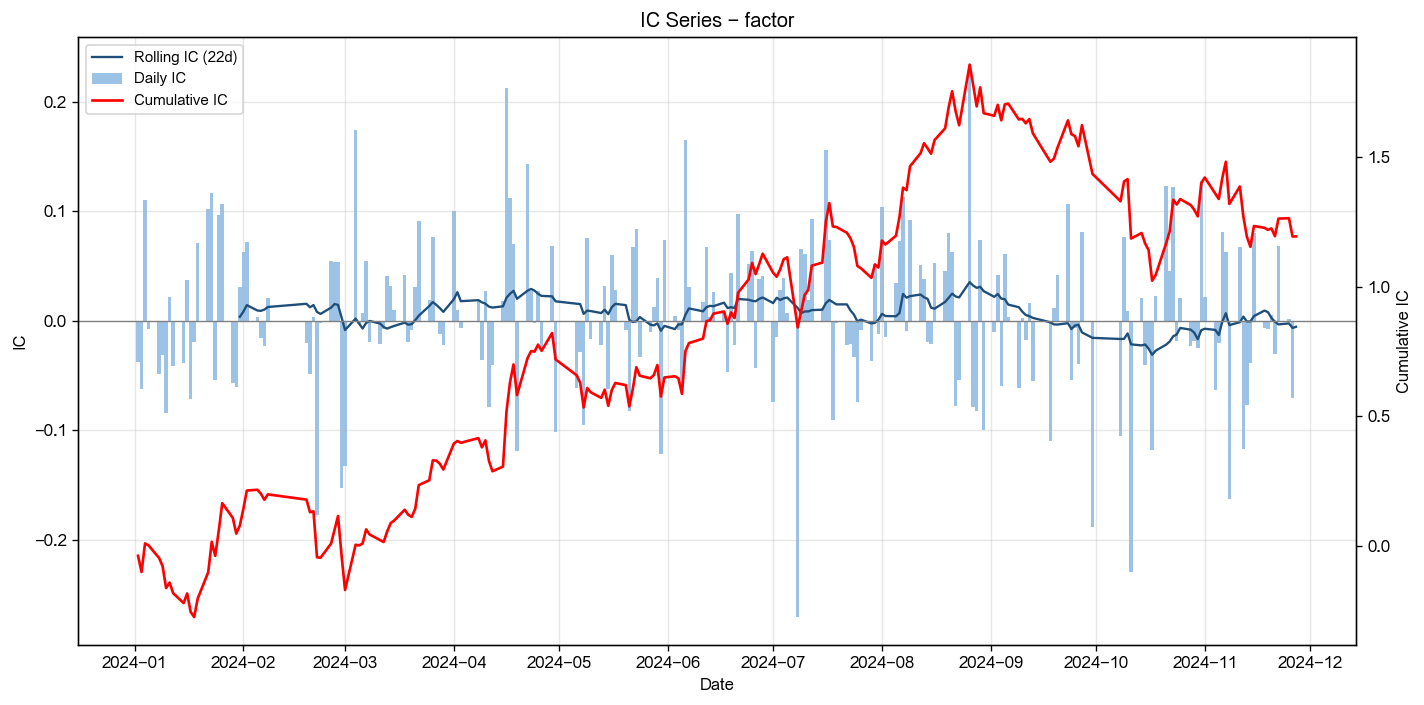
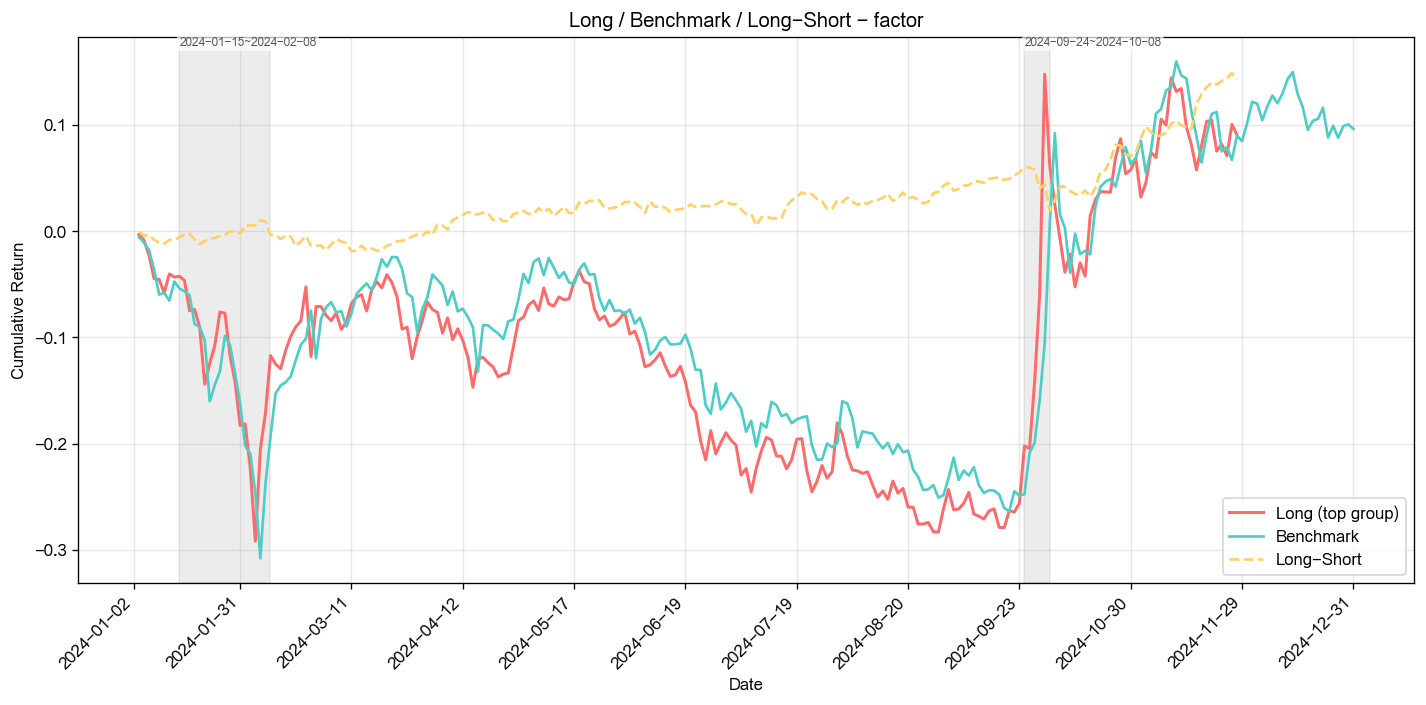
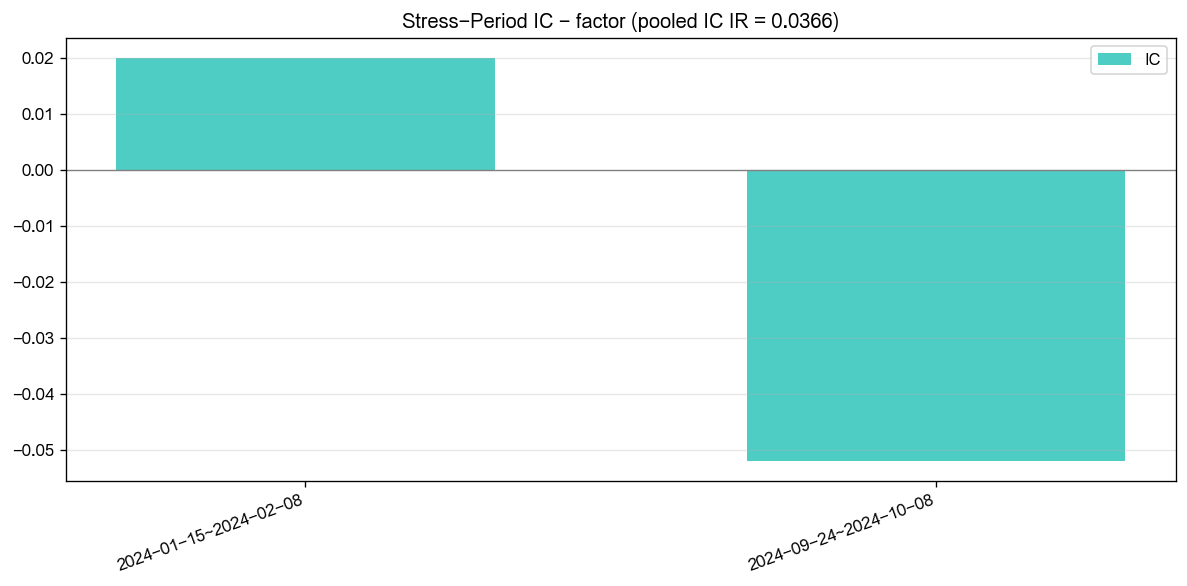
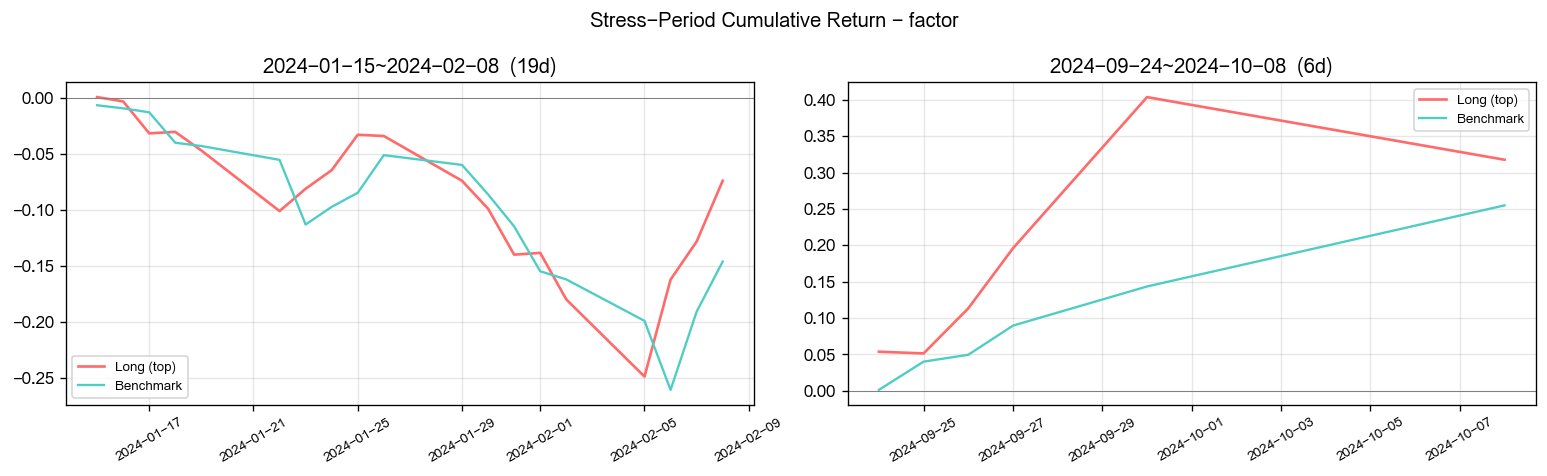

[2026-07-31 13:57:37] [info     ] ========== 因子池回归 ==========
[2026-07-31 13:57:37] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-31 13:57:37] [info     ] 获取收益率数据, 耗时: 0.7873 秒
[2026-07-31 13:57:38] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.0784 秒
[2026-07-31 13:57:38] [info     ] 统计 回归结果, 耗时: 0.0455 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9389,0.0446,0.0230,1.0000
2,factor,1.7785,0.0075,0.0042,0.9000
3,amount,1.7208,0.0186,0.0108,1.0000
4,netflow_amount_rate_main,1.5479,0.0100,0.0064,1.0000
5,gross_profit_rate_ttm,1.5146,0.0069,0.0046,1.0000
6,netflow_amount_main,1.5093,0.0252,0.0167,1.0000
7,net_profit_rate_ttm,1.4468,0.0040,0.0028,0.8000
8,pb,1.4218,0.0097,0.0068,1.0000
9,bias_20,1.4175,0.0292,0.0206,0.9000
10,cci_14,1.4021,0.0338,0.0241,1.0000

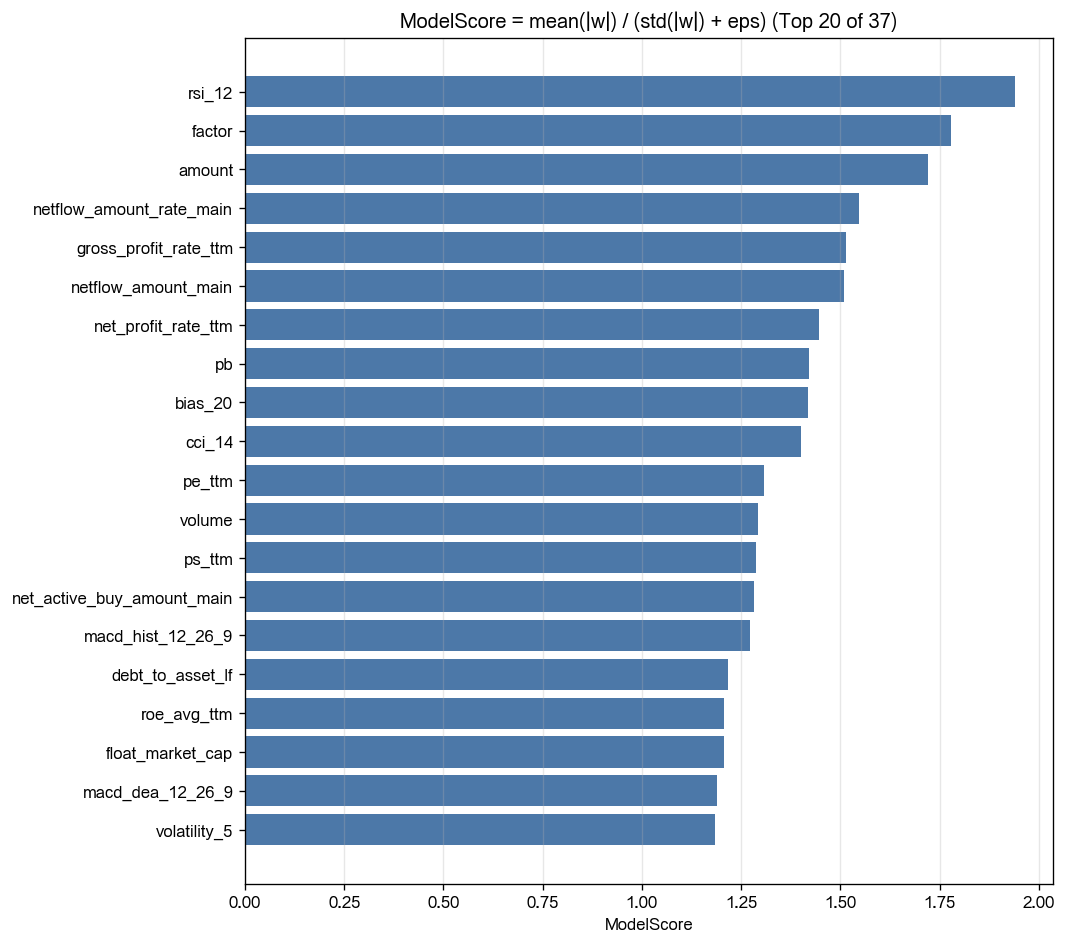
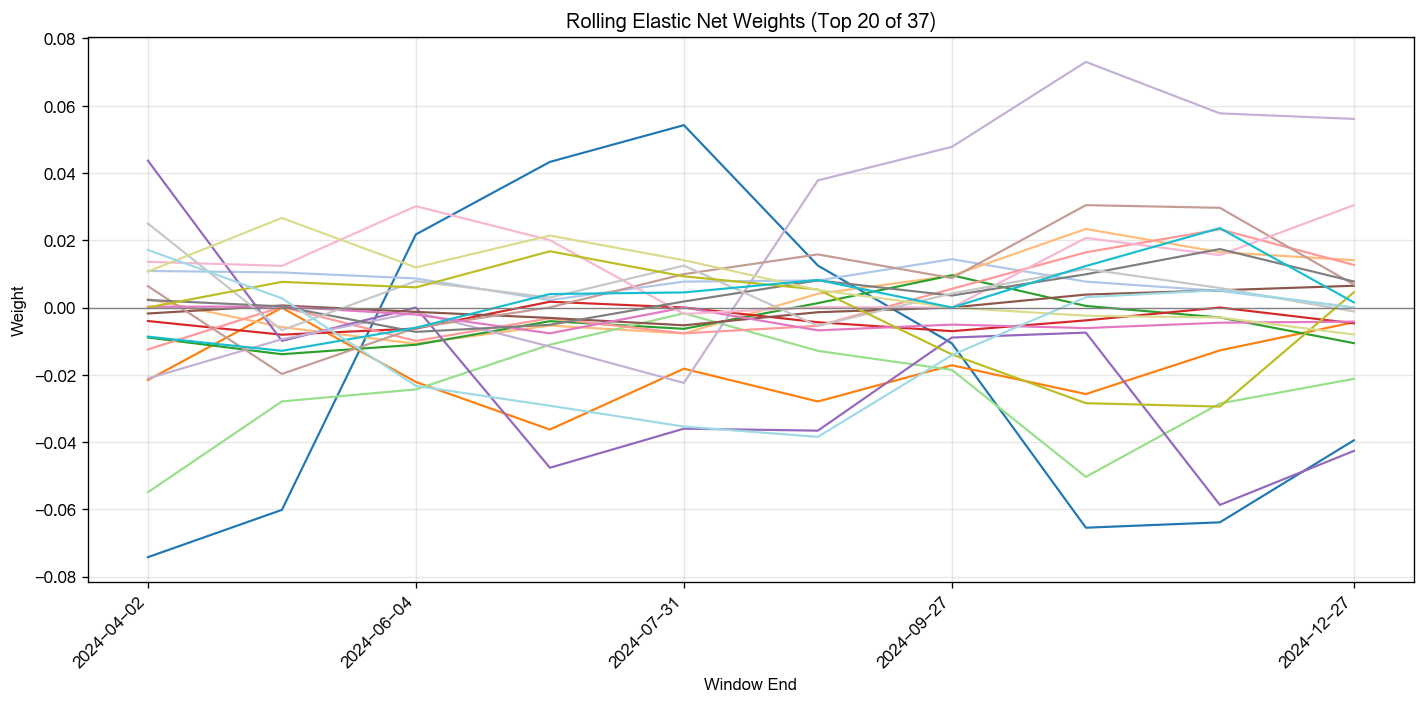
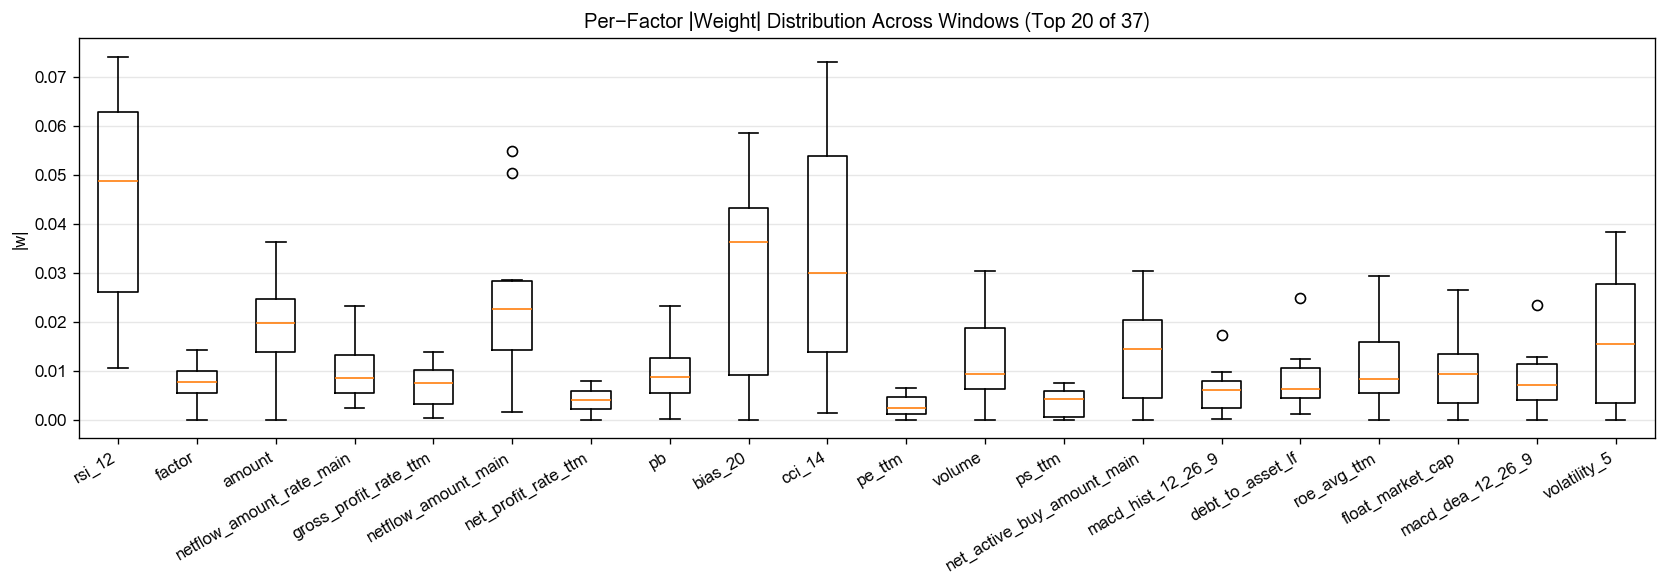
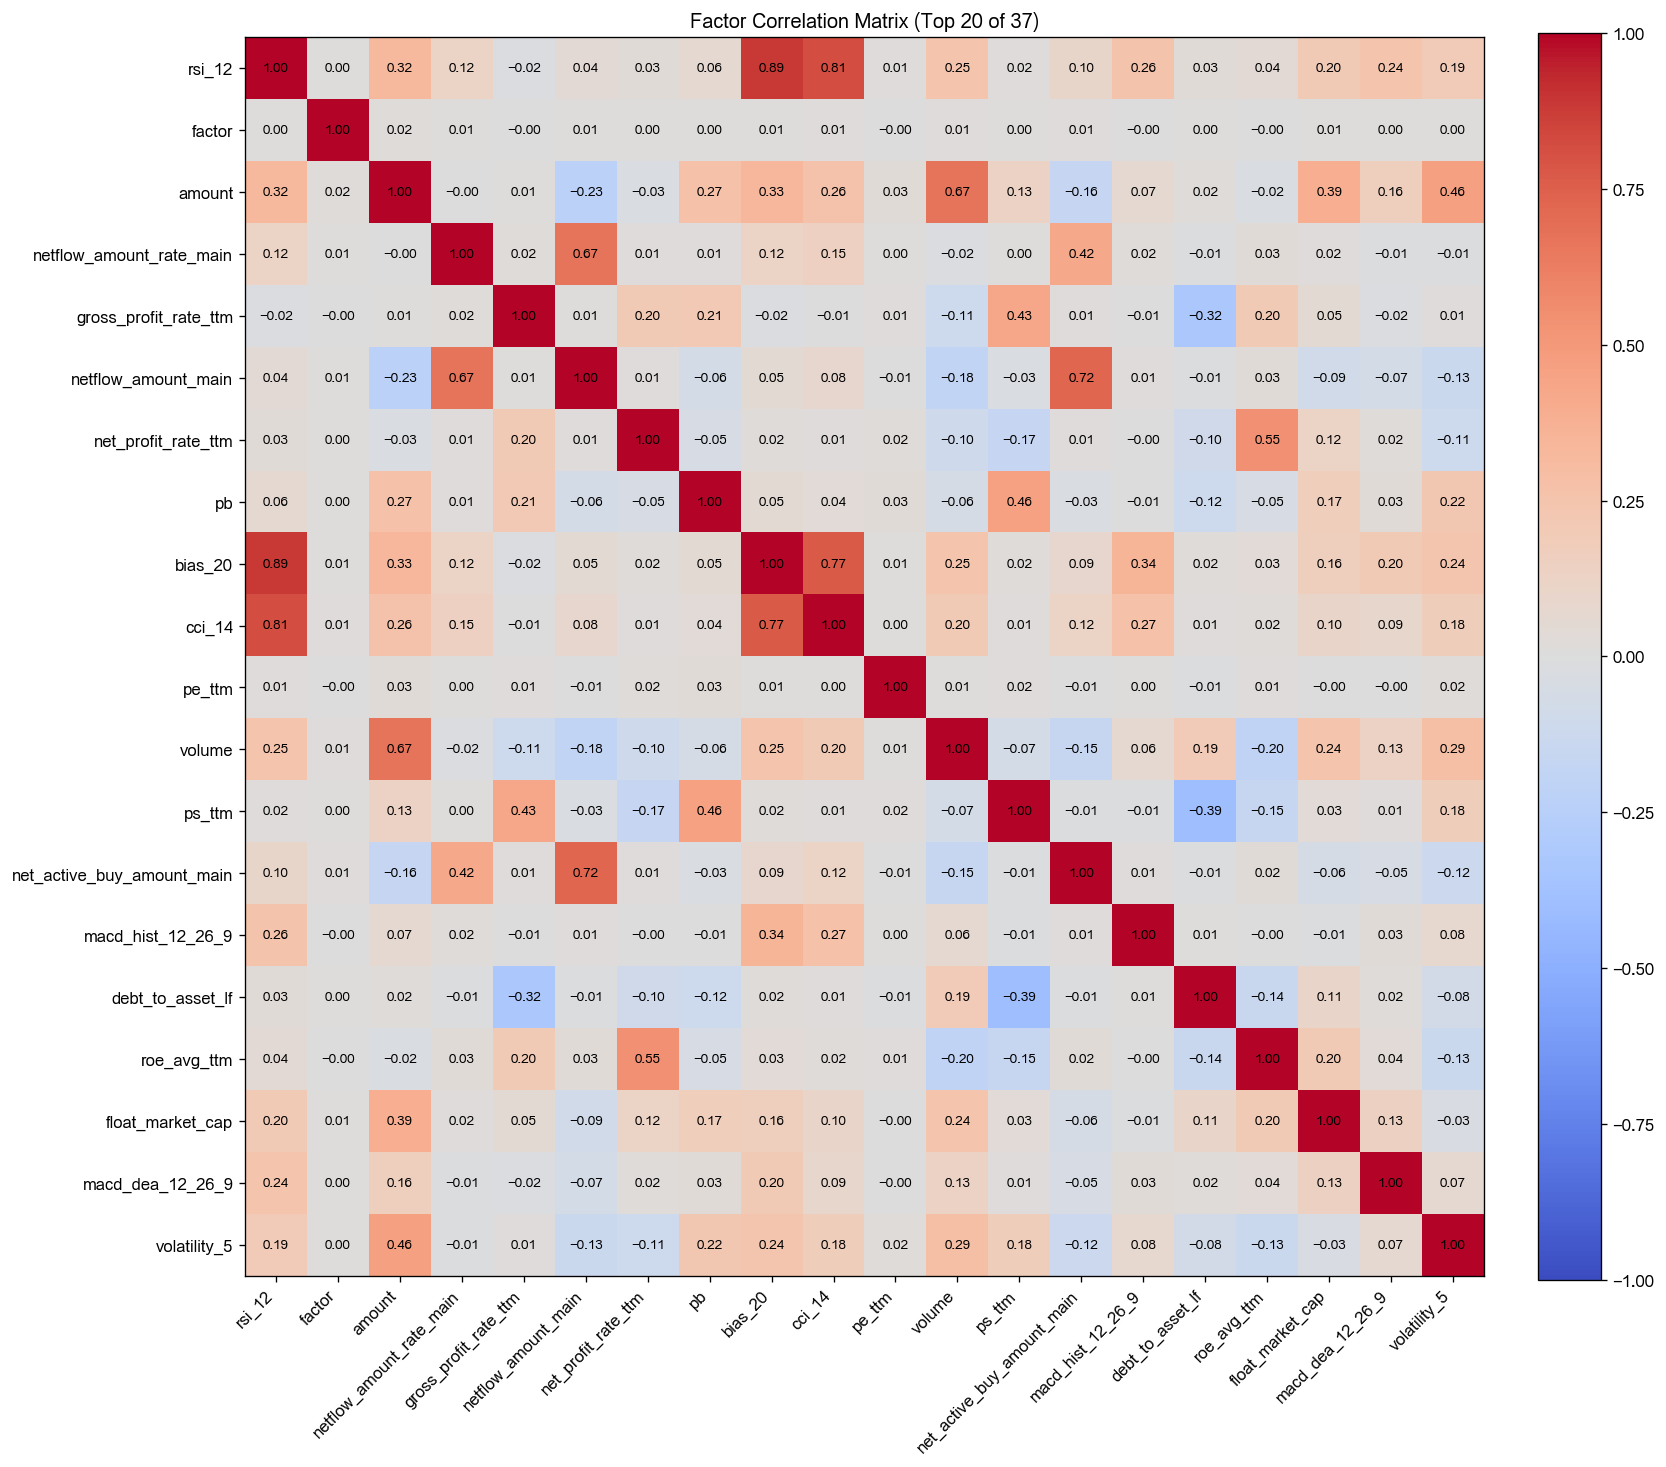

[2026-07-31 13:57:40] [warning  ] 返回的Outputs实例(size=33984840) 大于 64K, 将不会被缓存
[2026-07-31 13:57:40] [info     ] bigalpha_eval.v4 运行完成 [13.384s].

========== 可复制给大模型的 HOTR 因子回测结果（JSON） ==========
{
  "factor_name": "HOTR_stock_intraday_v1_projection_reversal",
  "factor_logic": {
    "version": "v1_causal_projection_reversal",
    "source_indicator": "Upshaw Home On The Range Price Projection Method",
    "algebra_fix": "同刻对称投影会使中点恒等于当前收盘价并退化为0；改为10:30生成投影、10:31后验证",
    "home_range": "09:31~10:30 的60分钟最高价减最低价",
    "projection_anchor": "10:30前最后一个有效分钟收盘价",
    "projection_q": 0.5,
    "evaluation": "尾盘30分钟投影位置 + 下午投影外超越强度",
    "weights": {
      "tail_position": 0.75,
      "afternoon_excess": 0.25
    },
    "direction": "下投影附近或下方的压力越强，因子越大；表达支撑位附近的次日截面反转预期",
    "data_frequency": "1分钟聚合为日频",
    "lookahead_control": "投影参数冻结后只使用更晚分钟，所有取末值操作显式排序"
  },
  "sample_period": {
    "start": "2024-01-01 00:00:00",
    "end": "2024-12-31 23:59:59"
  },
  "factor_data_stats": {
    "rows": 2420

In [1]:
def main(datasources, start_date, end_date):
    """
    构建适用于中证 1000 截面选股的 HOTR V4 T+1 方向校准因子。

    Excel 中的原始定义为：
        Range_t = max(H, n) - min(L, n)
        UpperProj_t = C_t + q * Range_t
        LowerProj_t = C_t - q * Range_t
        Factor_t = (C_t - mid(UpperProj_t, LowerProj_t)) / Range_t

    若上下投影和被检验价格都使用同一时刻的 C_t，投影中点恒等于 C_t，
    原式会代数退化为 0。这里继续采用“先投影、后验证”的因果修正：
    用 09:31~10:30 已完成的 60 分钟 Home Range 在 10:30 冻结投影，
    再用 10:31 之后的分钟路径判断投影边界的触碰、接受和后续反应。

    V3 已通过尾盘路径识别提高信号强度和回归稳定性，但平台结果显示：
    IC、ICIR、Sharpe 均为负，且 10 个滚动窗口中 9 个非零权重全部为负。
    这说明 V3 的同日路径状态与 T+1 截面收益存在稳定的反向映射，而非随机失效。
    V4 保留 V3 的全部事件结构与参数，仅对最终输出做统一的 T+1 方向校准：
      1. 只有分钟最高价/最低价真实触碰投影边界才激活；
      2. 触边后回到区间属于假突破，仍采用经典反转方向；
      3. 触边且守在边界附近，但尾盘动能衰减或远离日内极值，视为衰竭反转；
      4. 只有尾盘继续同向推进、收盘接近日内极值且早盘方向一致时，保留突破延续；
      5. 未触边、停牌或分钟数据残缺时返回中性值 0；
      6. 最终因子 = -1 × V3 原始路径状态，使较大值对应较高的 T+1 预期收益。

    评测时平台会替换 datasources / start_date / end_date 并调用本函数。
    返回值必须且仅包含 date、instrument、factor 三列，且因子值越大排名越靠前。
    """
    import numpy as np
    import pandas as pd
    import dai

    # 公榜、私榜会替换分钟数据物理表名，禁止硬编码比赛分钟表。
    bar1m = datasources["bar1m"]

    # ---------- HOTR V4 参数 ----------
    HOME_START = "09:31:00"
    HOME_END = "10:30:00"
    AFTERNOON_START = "13:01:00"
    PRE_TAIL_START = "14:01:00"
    PRE_TAIL_END = "14:30:00"
    TAIL_START = "14:31:00"
    MARKET_END = "15:00:00"

    # V3 的激活率约 40.7%，事件密度合理；V4 保持 q=0.75，不重新拟合事件阈值。
    PROJECTION_Q = 0.75

    # 尾盘均值抗单点噪声，最后一分钟保留真实收盘状态。
    TAIL_POSITION_WEIGHT = 0.75
    TERMINAL_POSITION_WEIGHT = 0.25

    # 首先判断投影边界是否被接受：结算位置为主，尾盘带外占比为辅。
    STATE_POSITION_WEIGHT = 0.75
    STATE_OCCUPANCY_WEIGHT = 0.25
    ACCEPTANCE_POSITION_PIVOT = 0.65
    ACCEPTANCE_POSITION_SCALE = 0.65
    ACCEPTANCE_OCCUPANCY_PIVOT = 0.20
    ACCEPTANCE_OCCUPANCY_SCALE = 0.35

    # 再判断被接受的突破是继续跟随还是已经衰竭。
    # 尾盘加速度权重最高；收盘效率衡量收盘是否仍靠近日内极值；
    # 早盘方向一致性只作较小确认，避免因子退化为普通日内动量。
    TAIL_IMPULSE_WEIGHT = 0.55
    CLOSE_EFFICIENCY_WEIGHT = 0.30
    HOME_ALIGNMENT_WEIGHT = 0.15
    TAIL_IMPULSE_SCALE = 0.50
    CLOSE_RETREAT_SCALE = 1.00
    HOME_ALIGNMENT_SCALE = 0.50
    FOLLOW_EVIDENCE_PIVOT = 0.25
    FOLLOW_EVIDENCE_SCALE = 0.75

    # 真实触边给基础强度；超过边界越深，事件置信度越高。
    TOUCH_BASE_STRENGTH = 0.35
    OVERSHOOT_FULL_STRENGTH = 0.75

    # 以下权重定义 V3 的同日路径状态；V4 完整保留，以维持 ModelScore 优势。
    FOLLOW_CONTINUATION_WEIGHT = 0.25
    EXHAUSTION_REVERSAL_WEIGHT = 0.45
    FAILED_BREAKOUT_REVERSAL_WEIGHT = 0.30
    TWO_SIDE_TOUCH_PENALTY = 0.25

    # V3 的 9 个非零滚动回归权重全部为负。赛事 ModelScore 使用绝对权重，
    # 因此只校准最终方向可在理论上保持 ModelScore，同时翻转 IC/ICIR/Sharpe。
    OUTPUT_DIRECTION = -1.0

    # 极小早盘波幅采用 30bp 尺度下限；位置与超越幅度只做坏点防护裁剪。
    RANGE_FLOOR_RATIO = 0.003
    POSITION_CLIP = 3.0
    OVERSHOOT_CLIP = 1.5

    # 标准交易日应有 60 根早盘参考 bar、180 根投影后 bar、120 根下午 bar、
    # 30 根尾盘前观察 bar 和 30 根尾盘 bar。
    MIN_HOME_BARS = 50
    MIN_POST_BARS = 150
    MIN_AFTERNOON_BARS = 100
    MIN_PRE_TAIL_BARS = 25
    MIN_TAIL_BARS = 25
    EPS = 1e-12

    # 只在同一交易日内执行“生成投影 -> 验证投影”，不使用未来日或跨日窗口。
    sql = f"""
    WITH cte_valid_1m AS (
        SELECT
            date,
            instrument,
            instrument_id,
            strftime(date, '%Y-%m-%d') AS trading_day,
            strftime(date, '%H:%M:%S') AS bar_clock,
            high,
            low,
            close
        FROM {bar1m}
        WHERE isfinite(high)
          AND isfinite(low)
          AND isfinite(close)
          AND high > 0
          AND low > 0
          AND close > 0
          AND high >= low
          AND high >= close
          AND low <= close
          -- 原始分钟表可能含集合竞价及无效快照，只保留标准 240 根连续竞价分钟 bar。
          AND (
              strftime(date, '%H:%M:%S') BETWEEN '09:31:00' AND '11:30:00'
              OR strftime(date, '%H:%M:%S') BETWEEN '13:01:00' AND '15:00:00'
          )
    ),
    cte_home_raw AS (
        SELECT
            instrument_id,
            instrument,
            trading_day,
            count(*) AS home_bar_count,
            max(high) AS home_high,
            min(low) AS home_low,
            -- first/last 均显式排序，保证不同物理表和未来函数自检结果一致。
            first(close ORDER BY date) AS home_start_close,
            last(close ORDER BY date) AS home_anchor
        FROM cte_valid_1m
        WHERE bar_clock BETWEEN '{HOME_START}' AND '{HOME_END}'
        GROUP BY instrument_id, instrument, trading_day
    ),
    cte_home_range AS (
        SELECT
            instrument_id,
            instrument,
            trading_day,
            home_bar_count,
            home_high,
            home_low,
            home_start_close,
            home_anchor,
            home_high - home_low AS raw_home_range,
            greatest(
                home_high - home_low,
                abs(home_anchor) * {RANGE_FLOOR_RATIO}
            ) AS effective_home_range
        FROM cte_home_raw
        WHERE home_bar_count >= {MIN_HOME_BARS}
          AND home_start_close > 0
          AND home_anchor > 0
          AND home_high - home_low > {EPS}
    ),
    cte_home AS (
        SELECT
            instrument_id,
            instrument,
            trading_day,
            home_anchor,
            raw_home_range,
            effective_home_range,
            greatest(
                -1.0,
                least(
                    1.0,
                    (home_anchor - home_start_close)
                    / greatest(effective_home_range, {EPS})
                )
            ) AS home_direction,
            {PROJECTION_Q} * effective_home_range AS projection_half_width,
            -- 在 10:30 冻结上下投影，后续价格不能反向修改投影水平。
            home_anchor + {PROJECTION_Q} * effective_home_range AS upper_projection,
            home_anchor - {PROJECTION_Q} * effective_home_range AS lower_projection
        FROM cte_home_range
    ),
    cte_post_raw AS (
        SELECT
            v.date,
            v.instrument,
            v.instrument_id,
            v.trading_day,
            v.bar_clock,
            v.high,
            v.low,
            v.close,
            h.home_anchor,
            h.home_direction,
            h.projection_half_width,
            h.upper_projection,
            h.lower_projection
        FROM cte_valid_1m AS v
        INNER JOIN cte_home AS h
          ON v.instrument_id = h.instrument_id
         AND v.instrument = h.instrument
         AND v.trading_day = h.trading_day
        -- 严格晚于投影生成时刻，避免同刻价格同时充当锚点和验证值。
        WHERE v.bar_clock > '{HOME_END}'
    ),
    cte_position AS (
        SELECT
            *,
            -- 投影中点是已冻结的 home_anchor，上下边界对应标准化位置 -1 / +1。
            greatest(
                -{POSITION_CLIP},
                least(
                    {POSITION_CLIP},
                    (close - home_anchor) / greatest(projection_half_width, {EPS})
                )
            ) AS close_position,
            greatest(
                -{POSITION_CLIP},
                least(
                    {POSITION_CLIP},
                    (high - home_anchor) / greatest(projection_half_width, {EPS})
                )
            ) AS high_position,
            greatest(
                -{POSITION_CLIP},
                least(
                    {POSITION_CLIP},
                    (low - home_anchor) / greatest(projection_half_width, {EPS})
                )
            ) AS low_position
        FROM cte_post_raw
    ),
    cte_projection_event AS (
        SELECT
            *,
            CASE WHEN high_position >= 1.0 THEN 1 ELSE 0 END AS upper_touch_flag,
            CASE WHEN low_position <= -1.0 THEN 1 ELSE 0 END AS lower_touch_flag,
            least(
                {OVERSHOOT_CLIP},
                greatest(0.0, high_position - 1.0)
            ) AS upper_overshoot,
            least(
                {OVERSHOOT_CLIP},
                greatest(0.0, -1.0 - low_position)
            ) AS lower_overshoot
        FROM cte_position
    ),
    cte_daily AS (
        SELECT
            trading_day,
            instrument,
            count(*) AS post_bar_count,
            max(date) AS last_bar_time,
            max(home_direction) AS home_direction,
            count(CASE
                WHEN bar_clock BETWEEN '{AFTERNOON_START}' AND '{MARKET_END}'
                THEN close_position
            END) AS afternoon_valid_count,
            count(CASE
                WHEN bar_clock BETWEEN '{PRE_TAIL_START}' AND '{PRE_TAIL_END}'
                THEN close_position
            END) AS pre_tail_valid_count,
            count(CASE
                WHEN bar_clock BETWEEN '{TAIL_START}' AND '{MARKET_END}'
                THEN close_position
            END) AS tail_valid_count,

            max(upper_touch_flag) AS upper_touch_flag,
            max(lower_touch_flag) AS lower_touch_flag,
            max(upper_overshoot) AS upper_overshoot,
            max(lower_overshoot) AS lower_overshoot,
            max(high_position) AS post_high_position,
            min(low_position) AS post_low_position,

            -- 比较 14:01~14:30 与尾盘，用于识别触边后的继续推进或动能衰竭。
            avg(CASE
                WHEN bar_clock BETWEEN '{PRE_TAIL_START}' AND '{PRE_TAIL_END}'
                THEN close_position
            END) AS pre_tail_position,
            avg(CASE
                WHEN bar_clock BETWEEN '{TAIL_START}' AND '{MARKET_END}'
                THEN close_position
            END) AS tail_position,
            last(close_position ORDER BY date) AS terminal_position,

            -- 尾盘收盘价位于投影带外的比例，用于判断边界是否被市场持续接受。
            avg(CASE
                WHEN bar_clock BETWEEN '{TAIL_START}' AND '{MARKET_END}'
                THEN CASE WHEN close_position >= 1.0 THEN 1.0 ELSE 0.0 END
            END) AS tail_upper_occupancy,
            avg(CASE
                WHEN bar_clock BETWEEN '{TAIL_START}' AND '{MARKET_END}'
                THEN CASE WHEN close_position <= -1.0 THEN 1.0 ELSE 0.0 END
            END) AS tail_lower_occupancy
        FROM cte_projection_event
        GROUP BY trading_day, instrument
    ),
    cte_event_strength AS (
        SELECT
            *,
            {TAIL_POSITION_WEIGHT} * tail_position
                + {TERMINAL_POSITION_WEIGHT} * terminal_position
                AS settlement_position,
            CASE
                WHEN upper_touch_flag = 1
                THEN {TOUCH_BASE_STRENGTH}
                    + (1.0 - {TOUCH_BASE_STRENGTH}) * least(
                        1.0,
                        upper_overshoot / {OVERSHOOT_FULL_STRENGTH}
                    )
                ELSE 0.0
            END AS upper_touch_strength,
            CASE
                WHEN lower_touch_flag = 1
                THEN {TOUCH_BASE_STRENGTH}
                    + (1.0 - {TOUCH_BASE_STRENGTH}) * least(
                        1.0,
                        lower_overshoot / {OVERSHOOT_FULL_STRENGTH}
                    )
                ELSE 0.0
            END AS lower_touch_strength
        FROM cte_daily
    ),
    cte_acceptance_state AS (
        SELECT
            *,
            -- 正值表示上投影被接受，负值表示冲高后回到投影带内。
            {STATE_POSITION_WEIGHT} * greatest(
                -1.0,
                least(
                    1.0,
                    (settlement_position - {ACCEPTANCE_POSITION_PIVOT})
                    / {ACCEPTANCE_POSITION_SCALE}
                )
            )
            + {STATE_OCCUPANCY_WEIGHT} * greatest(
                -1.0,
                least(
                    1.0,
                    (tail_upper_occupancy - {ACCEPTANCE_OCCUPANCY_PIVOT})
                    / {ACCEPTANCE_OCCUPANCY_SCALE}
                )
            ) AS upper_acceptance_state,

            -- 对下投影使用镜像坐标，确保上下方向完全对称。
            {STATE_POSITION_WEIGHT} * greatest(
                -1.0,
                least(
                    1.0,
                    (-settlement_position - {ACCEPTANCE_POSITION_PIVOT})
                    / {ACCEPTANCE_POSITION_SCALE}
                )
            )
            + {STATE_OCCUPANCY_WEIGHT} * greatest(
                -1.0,
                least(
                    1.0,
                    (tail_lower_occupancy - {ACCEPTANCE_OCCUPANCY_PIVOT})
                    / {ACCEPTANCE_OCCUPANCY_SCALE}
                )
            ) AS lower_acceptance_state
        FROM cte_event_strength
    ),
    cte_path_inputs AS (
        SELECT
            *,
            -- 同方向尾盘加速：上方用“尾盘减尾盘前”，下方使用镜像方向。
            greatest(
                -1.0,
                least(
                    1.0,
                    (settlement_position - pre_tail_position) / {TAIL_IMPULSE_SCALE}
                )
            ) AS upper_tail_impulse,
            greatest(
                -1.0,
                least(
                    1.0,
                    (pre_tail_position - settlement_position) / {TAIL_IMPULSE_SCALE}
                )
            ) AS lower_tail_impulse,

            -- 收盘效率：越靠近日内同侧极值越接近 +1，回撤一个投影半宽后降至 -1。
            1.0 - 2.0 * greatest(
                0.0,
                least(
                    1.0,
                    (post_high_position - terminal_position) / {CLOSE_RETREAT_SCALE}
                )
            ) AS upper_close_efficiency,
            1.0 - 2.0 * greatest(
                0.0,
                least(
                    1.0,
                    (terminal_position - post_low_position) / {CLOSE_RETREAT_SCALE}
                )
            ) AS lower_close_efficiency,

            greatest(
                -1.0,
                least(1.0, home_direction / {HOME_ALIGNMENT_SCALE})
            ) AS upper_home_alignment,
            greatest(
                -1.0,
                least(1.0, -home_direction / {HOME_ALIGNMENT_SCALE})
            ) AS lower_home_alignment
        FROM cte_acceptance_state
    ),
    cte_follow_state AS (
        SELECT
            *,
            greatest(
                -1.0,
                least(
                    1.0,
                    (
                        {TAIL_IMPULSE_WEIGHT} * upper_tail_impulse
                        + {CLOSE_EFFICIENCY_WEIGHT} * upper_close_efficiency
                        + {HOME_ALIGNMENT_WEIGHT} * upper_home_alignment
                        - {FOLLOW_EVIDENCE_PIVOT}
                    ) / {FOLLOW_EVIDENCE_SCALE}
                )
            ) AS upper_follow_state,
            greatest(
                -1.0,
                least(
                    1.0,
                    (
                        {TAIL_IMPULSE_WEIGHT} * lower_tail_impulse
                        + {CLOSE_EFFICIENCY_WEIGHT} * lower_close_efficiency
                        + {HOME_ALIGNMENT_WEIGHT} * lower_home_alignment
                        - {FOLLOW_EVIDENCE_PIVOT}
                    ) / {FOLLOW_EVIDENCE_SCALE}
                )
            ) AS lower_follow_state
        FROM cte_path_inputs
    ),
    cte_components AS (
        SELECT
            *,
            -- 被接受且仍有强跟随压力：保留突破延续。
            upper_touch_strength
                * greatest(upper_acceptance_state, 0.0)
                * greatest(upper_follow_state, 0.0)
                AS upper_follow_continuation,
            lower_touch_strength
                * greatest(lower_acceptance_state, 0.0)
                * greatest(lower_follow_state, 0.0)
                AS lower_follow_continuation,

            -- 被接受但尾盘不再跟随：解释为投影极值附近的衰竭。
            upper_touch_strength
                * greatest(upper_acceptance_state, 0.0)
                * greatest(-upper_follow_state, 0.0)
                AS upper_exhaustion_reversal,
            lower_touch_strength
                * greatest(lower_acceptance_state, 0.0)
                * greatest(-lower_follow_state, 0.0)
                AS lower_exhaustion_reversal,

            -- 回到投影带内的假突破继续采用经典反转方向。
            upper_touch_strength * greatest(-upper_acceptance_state, 0.0)
                AS upper_failed_breakout,
            lower_touch_strength * greatest(-lower_acceptance_state, 0.0)
                AS lower_failed_breakout,

            -- 同日双边均被深度触碰通常代表高波动震荡，适度降低其置信度。
            1.0 - {TWO_SIDE_TOUCH_PENALTY} * least(
                upper_touch_strength,
                lower_touch_strength
            ) AS path_clarity
        FROM cte_follow_state
    ),
    cte_factor AS (
        SELECT
            trading_day,
            instrument,
            CASE
                WHEN post_bar_count >= {MIN_POST_BARS}
                 AND afternoon_valid_count >= {MIN_AFTERNOON_BARS}
                 AND pre_tail_valid_count >= {MIN_PRE_TAIL_BARS}
                 AND tail_valid_count >= {MIN_TAIL_BARS}
                 AND strftime(last_bar_time, '%H:%M:%S') >= '14:55:00'
                 AND (upper_touch_flag = 1 OR lower_touch_flag = 1)
                THEN path_clarity * (
                    -- 强跟随上破为正、强跟随下破为负。
                    {FOLLOW_CONTINUATION_WEIGHT} * (
                        upper_follow_continuation - lower_follow_continuation
                    )
                    -- 上方衰竭为负、下方衰竭为正。
                    + {EXHAUSTION_REVERSAL_WEIGHT} * (
                        lower_exhaustion_reversal - upper_exhaustion_reversal
                    )
                    -- 上方假突破为负、下方假突破为正。
                    + {FAILED_BREAKOUT_REVERSAL_WEIGHT} * (
                        lower_failed_breakout - upper_failed_breakout
                    )
                )
                -- 无投影事件或数据质量不足时给中性值，保证覆盖但不伪造方向。
                ELSE 0.0
            END AS raw_factor
        FROM cte_components
    )
    SELECT
        CAST(trading_day AS DATETIME) AS date,
        instrument,
        CASE
            -- V4 唯一的预测层改动：将稳定反向的 V3 路径状态校准为 T+1 正向排序。
            WHEN isfinite(raw_factor) THEN {OUTPUT_DIRECTION} * raw_factor
            ELSE 0.0
        END AS factor
    FROM cte_factor
    """

    # compression=True 可显著降低大规模分钟查询中 instrument 字符串列的内存占用。
    factor_df = dai.query(
        sql,
        filters={"date": [start_date, end_date]},
        compression=True,
    ).df()

    # 动态对齐历史时点的中证 1000 成分股。辅助股票池不会被评测系统替换，
    # 因此按赛事官方要求直接查询 bigalpha_2026_instruments。
    stock_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]},
        compression=True,
    ).df()

    factor_df = factor_df[["date", "instrument", "factor"]].copy()
    stock_pool = stock_pool[["date", "instrument"]].copy()

    # 统一到交易日零点，避免分钟聚合日期与股票池日期时间部分不同而连接失败。
    factor_df["date"] = pd.to_datetime(factor_df["date"]).dt.normalize()
    stock_pool["date"] = pd.to_datetime(stock_pool["date"]).dt.normalize()
    factor_df["instrument"] = factor_df["instrument"].astype(str)
    stock_pool["instrument"] = stock_pool["instrument"].astype(str)

    factor_df = factor_df.drop_duplicates(["date", "instrument"], keep="last")
    stock_pool = stock_pool.drop_duplicates(["date", "instrument"], keep="last")
    result = pd.merge(
        stock_pool,
        factor_df,
        how="left",
        on=["date", "instrument"],
        validate="one_to_one",
    )

    # 缺分钟、停牌及所有非有限结果统一设为中性值 0，确保逐日覆盖与有限值校验。
    result["factor"] = (
        pd.to_numeric(result["factor"], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .astype(float)
    )

    # 因子按个股 Home Range 无量纲化，可直接用于每日股票截面比较。
    # 平台后续统一执行去极值、标准化与 BARRA 风格剔除，这里不重复处理。
    start_day = pd.to_datetime(start_date).normalize()
    end_day = pd.to_datetime(end_date).normalize()
    result = result[(result["date"] >= start_day) & (result["date"] <= end_day)]
    df = (
        result[["date", "instrument", "factor"]]
        .sort_values(["date", "instrument"])
        .reset_index(drop=True)
    )
    return df




if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    # 本地自测时自行构造数据源映射（评测时由平台注入，逻辑名固定为 "bar1m"/"financial"）
    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    # 计算因子
    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    # 读取平台因子库用于回归评估，您可以换成自己的因子库
    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    # 评估系统：
    # process_pools=False 表示不对因子库再做预处理（bigalpha_2026_factorlib 已处理过）
    # show=True 表示画出评估图表
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )


    # ===== 打印可直接复制给大模型的 HOTR 回测摘要 =====
    # 比赛平台只提取并执行 main()；本段位于 main() 外，仅用于平台 Notebook 自测。
    import json
    import math

    def _read_field(obj, field):
        """兼容字典键和对象属性两种评估结果结构。"""
        if obj is None:
            return None
        if isinstance(obj, dict):
            return obj.get(field)
        return getattr(obj, field, None)

    def _find_section(field):
        """从评估返回值、_result、_detail 中寻找指定结果块。"""
        containers = [
            result,
            getattr(result, "_result", None),
            getattr(result, "_detail", None),
        ]
        if isinstance(result, dict):
            containers.extend([result.get("_result"), result.get("_detail")])

        for container in containers:
            value = _read_field(container, field)
            if value is not None:
                return value
        for container in containers:
            if isinstance(container, dict):
                for child in container.values():
                    value = _read_field(child, field)
                    if value is not None:
                        return value
        return None

    def _json_ready(value, max_rows=100):
        """将常见平台对象转成紧凑、合法且便于复制的 JSON 数据。"""
        if value is None or isinstance(value, (str, bool, int)):
            return value
        if isinstance(value, float):
            return value if math.isfinite(value) else None
        if isinstance(value, dict):
            return {
                str(key): _json_ready(item, max_rows)
                for key, item in value.items()
            }
        if isinstance(value, (list, tuple)):
            return [_json_ready(item, max_rows) for item in value[:max_rows]]
        if hasattr(value, "model_dump"):
            try:
                return _json_ready(value.model_dump(), max_rows)
            except Exception:
                pass
        if hasattr(value, "columns") and hasattr(value, "to_dict"):
            try:
                table = value.head(max_rows) if hasattr(value, "head") else value
                return _json_ready(table.to_dict(orient="records"), max_rows)
            except Exception:
                pass
        if hasattr(value, "to_dict"):
            try:
                return _json_ready(value.to_dict(), max_rows)
            except Exception:
                pass
        if hasattr(value, "tolist"):
            try:
                return _json_ready(value.tolist(), max_rows)
            except Exception:
                pass
        if hasattr(value, "item"):
            try:
                return _json_ready(value.item(), max_rows)
            except Exception:
                pass
        if hasattr(value, "isoformat"):
            try:
                return value.isoformat()
            except Exception:
                pass
        return str(value)

    factor_analyze = _find_section("factor_analyze")
    factor_regression = _find_section("factor_regression")
    per_factor_scores = _read_field(factor_regression, "per_factor_scores")
    weights_history = _read_field(factor_regression, "weights_history")

    copy_payload = {
        "factor_name": "HOTR_stock_intraday_v1_projection_reversal",
        "factor_logic": {
            "version": "v1_causal_projection_reversal",
            "source_indicator": "Upshaw Home On The Range Price Projection Method",
            "algebra_fix": (
                "同刻对称投影会使中点恒等于当前收盘价并退化为0；"
                "改为10:30生成投影、10:31后验证"
            ),
            "home_range": "09:31~10:30 的60分钟最高价减最低价",
            "projection_anchor": "10:30前最后一个有效分钟收盘价",
            "projection_q": 0.5,
            "evaluation": "尾盘30分钟投影位置 + 下午投影外超越强度",
            "weights": {"tail_position": 0.75, "afternoon_excess": 0.25},
            "direction": (
                "下投影附近或下方的压力越强，因子越大；"
                "表达支撑位附近的次日截面反转预期"
            ),
            "data_frequency": "1分钟聚合为日频",
            "lookahead_control": "投影参数冻结后只使用更晚分钟，所有取末值操作显式排序",
        },
        "sample_period": {"start": start_date, "end": end_date},
        "factor_data_stats": {
            "rows": int(len(factor_data)),
            "trading_days": int(factor_data["date"].nunique()),
            "instruments": int(factor_data["instrument"].nunique()),
            "factor_mean": float(factor_data["factor"].mean()),
            "factor_std": float(factor_data["factor"].std()),
            "factor_min": float(factor_data["factor"].min()),
            "factor_max": float(factor_data["factor"].max()),
            "zero_ratio": float((factor_data["factor"] == 0).mean()),
        },
        "factor_analyze": _json_ready(factor_analyze),
        "per_factor_scores": _json_ready(per_factor_scores),
        # 回归权重可能很长，只保留前 100 条，便于复制并判断权重稳定性。
        "weights_history_first_100": _json_ready(weights_history, max_rows=100),
    }

    print("\n========== 可复制给大模型的 HOTR 因子回测结果（JSON） ==========")
    print(json.dumps(_json_ready(copy_payload), ensure_ascii=False, indent=2))
    print("========== HOTR 因子回测结果结束 ==========\n")

    if factor_analyze is None:
        print("提示：当前平台版本未定位到 factor_analyze；可一并复制评估日志中的 IC/ICIR/Sharpe。")
    if per_factor_scores is None:
        print("提示：当前平台版本未定位到 per_factor_scores；可检查 result._detail 的实际字段名。")